Multi Agent RAG

- multi agent network

api keys and LLM setup

In [2]:
import os
from dotenv import load_dotenv
load_dotenv()
from langchain.chat_models import init_chat_model
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

llm = init_chat_model("groq:llama-3.1-8b-instant")
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.11'}}, output_version=None, profile={'name': 'Llama 3.1 8B Instant', 'release_date': '2024-07-23', 'last_updated': '2024-07-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 131072, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x0000027DB3F11DC0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000027DB591A5A0>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

Building the individual agents
- researcher agent
- blog writer agent

In [5]:
#libraries
from typing import Annotated,Literal
from langchain_tavily import TavilySearch
from langchain_core.tools import tool,Tool
from langchain_community.utilities.wikidata import WikidataAPIWrapper
from langchain_community.tools.wikipedia.tool import WikipediaQueryRun
from langchain_community.document_loaders import TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings

C:\Users\Dell\AppData\Local\Temp\ipykernel_1156\2315101976.py:5: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.utilities.wikidata import WikidataAPIWrapper


building the tools

In [6]:
tavily_tool = TavilySearch(max_results=5)
tavily_tool

TavilySearch(max_results=5, api_wrapper=TavilySearchAPIWrapper(tavily_api_key=SecretStr('**********'), api_base_url=None))

In [21]:
def make_retriever_tool_from_text(file,name,desc):
    docs = TextLoader(file,encoding="utf-8").load()
    chunks = RecursiveCharacterTextSplitter(chunk_size=500,chunk_overlap=50).split_documents(docs)
    vs = FAISS.from_documents(chunks,HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2"))
    retriever = vs.as_retriever()
    
    def tool_func(query: str) -> str:
        result = retriever.invoke(query)
        return "\n\n".join(doc.page_content for doc in result)
    
    return Tool(name=name,description=desc,func=tool_func)

internal_tool_1 = make_retriever_tool_from_text("research_notes.txt","ResearchNotesTool","Search research notes for projects and other information")
internal_tool_1

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Tool(name='ResearchNotesTool', description='Search research notes for projects and other information', func=<function make_retriever_tool_from_text.<locals>.tool_func at 0x0000027DC94972E0>)

In [8]:
from langchain_core.messages import BaseMessage, HumanMessage
from langgraph.graph import MessagesState,END
from langchain.agents import create_agent
from langgraph.types import Command

def get_nextnode(last_message: BaseMessage,goto: str):
    content = last_message.content
    if isinstance(content,str) and 'FINAL ANSWER' in last_message.content:
        return END
    return goto

In [9]:
def make_system_prompt(suffix: str) -> str:
    return (
        f"""You are a helpful AI assistant, collaborating with other assitants.
        Use the provided tools to progress towards answering the question
        If you are unable to fully answer, thats OK, another assitant with different tools
        will help where you left off. Execute what you can to make progress.
        If you or any of the other assitants have the final answer or deliverbale,
        prefix your response with FINAL ANSWER so the team knows to stop.
        \n{suffix}"""
    )

Building the Research Agent and Node

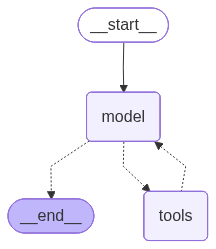

In [10]:
research_agent = create_agent(
    llm,
    tools=[internal_tool_1,tavily_tool],
)
research_agent

In [11]:
def research_node(state: MessagesState) -> Command[Literal["blog_generator",END]]:
    result = research_agent.invoke({
        "messages":[
            {
                "role":"system",
                "content":make_system_prompt("You can only do research. You are working with a content writer colleague."),
            },
            *state['messages'],
        ]
    })
    goto = get_nextnode(result["messages"][-1],"blog_generator")
    # not all providers allow ai msg since wrapping it in human message
    result["messages"][-1] = HumanMessage(
        content=result["messages"][-1].content,
        name="researcher"
    )
    return Command(
        update={
            "messages":result["messages"]
        },
        goto=goto
    )

Building the Blog Writer Agent and Node

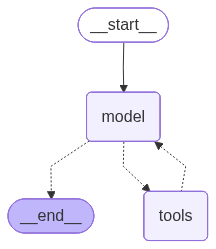

In [12]:
blog_agent = create_agent(
    llm,
    tools=[tavily_tool]
)
blog_agent

In [13]:
def blog_node(state: MessagesState) -> Command[Literal["researcher",END]]:
    result = blog_agent.invoke({
        "messages":[
            {
                "role":"system",
                "content":make_system_prompt("You can only write a detailed blog. You are working with a researcher colleague."),
            },
            *state['messages']
        ]
    })
    goto = get_nextnode(result["messages"][-1],"researcher")
    result["messages"][-1] = HumanMessage(
        content=result["messages"][-1].content,
        name="blog_generator"
    )
    return Command(
        update={
            "messages":result["messages"]
        },
        goto=goto
    )

building the graph

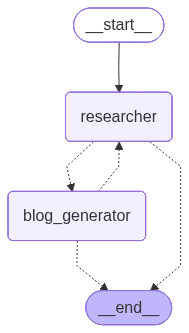

In [14]:
from langgraph.graph import StateGraph,START
workflow = StateGraph(MessagesState)
workflow.add_node("researcher",research_node)
workflow.add_node("blog_generator",blog_node)
workflow.add_edge(START,"researcher")
graph = workflow.compile()
graph

testing the system

In [ ]:
response = graph.invoke(
    {
        "messages": [
            {"role": "user", "content": "Write a detailed blog on project Falcon, Nova and Atlas"}
        ]
    },
    config={"recursion_limit": 25}
)
response

Supervisor Multi Agent RAG

renaming tavily tool

In [15]:
from langchain_tavily import TavilySearch

web_search = TavilySearch(max_results=3)
web_search

TavilySearch(max_results=3, api_wrapper=TavilySearchAPIWrapper(tavily_api_key=SecretStr('**********'), api_base_url=None))

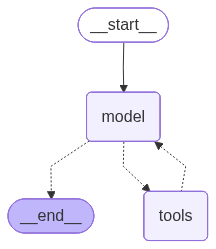

In [22]:
research_agent =  create_agent(
    model=llm,
    tools=[web_search,internal_tool_1],
system_prompt = """You are a research agent.
INSTRUCTIONS:\n
- assist only with research-related tasks, do not do any math\n
- after youre done with your tasks,respond to the supervisor directly\n
- respond only with the results of your work, do not include any other text.""",
name="research_agent"
)
research_agent

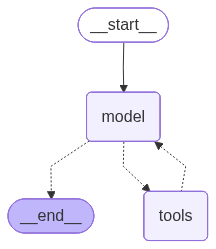

In [26]:
def add(a: float, b: float):
    """Add two numbers"""
    return a+b


def multiply(a: float, b: float):
    """Multiply two numbers"""
    return a*b


def divide(a: float, b: float):
    """Divide two numbers"""
    return a / b


math_agent = create_agent(
    model=llm,
    tools=[add, multiply, divide],
    system_prompt="""You are a math agent.
INSTRUCTIONS:\n
- assist only with math related tasks, do not do any research\n
- after youre done with your tasks,respond to the supervisor directly\n
- respond only with the results of your work, do not include any other text.""",
name="math_agent"
)
math_agent

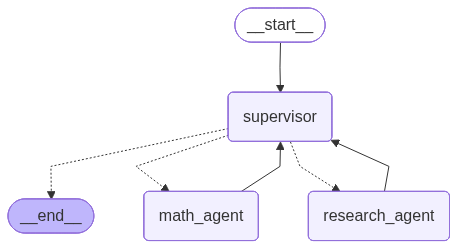

In [27]:
from langgraph_supervisor import create_supervisor

supervisor = create_supervisor(
    model=llm,
    agents=[research_agent,math_agent],
    prompt=(
        "You are a supervisor managing two agents:\n"
        "- a research agent. Assign research-related tasks to this agent\n" \
        "- a math agent. Assign math-related tasks to this agent.\n" \
        "Assign work to one agent at a time, do not call agents in parallel." \
        "Do not do any work yourself"
    ),
    add_handoff_back_messages=True,
    output_mode="full_history"
).compile()
supervisor

In [ ]:
response = supervisor.invoke({"messages":"List all the projects and their data from the retriever and tell me what is 5 plus 10"})

Hierarchical Agent Architecture with RAG

In [7]:
#libraries
from typing import Annotated,Literal,List
from langchain_tavily import TavilySearch
from langchain_core.tools import tool,Tool
from langchain_community.utilities.wikidata import WikidataAPIWrapper
from langchain_community.tools.wikipedia.tool import WikipediaQueryRun
from langchain_community.document_loaders import TextLoader,WebBaseLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings

In [4]:
tavily_tool = TavilySearch(max_results=5)

web scraper tool

In [8]:
@tool
def scrape_webpages(urls: List[str]) -> str:
    """Use requests and bs4 to scrape the provided webpades for detailed information"""
    loader = WebBaseLoader(urls)
    docs = loader.load()
    return "\n\n".join(
        [
            f'<Document name="{doc.metadata.get("title","")}">\n{doc.page_content}\n</Document>'
            for doc in docs
        ]
    )

chart creator tool

In [33]:
from pathlib import Path
from tempfile import TemporaryDirectory
from typing import Dict, Optional
from typing_extensions import TypedDict
from langchain_experimental.utilities import PythonREPL

_TEMP_DIRECTORY = TemporaryDirectory()
WORKING_DIRECTORY = Path(_TEMP_DIRECTORY.name)

@tool
def create_outline(
    points:Annotated[List[str],"List of main points or sections"],
    file_name:Annotated[str,"File path to save the outline"]
) -> Annotated[str,"Path of the saved outline file"]:
    """Create and save an outline"""
    with(WORKING_DIRECTORY / file_name).open("w") as file:
        for i,point in enumerate(points):
            file.write(f"{i+1}. {point}\n")
    return f"Outline saved to {file_name}"

write document tool

In [10]:
@tool
def write_document(
    content: Annotated[str,"Text content to be written into document"],
    file_name: Annotated[str,"File path to save the document"]
) -> Annotated[str,"Path of the saved document file"]:
    """Create and save a text document"""
    with (WORKING_DIRECTORY/file_name).open("w") as file:
        file.write(content)
    return f"Document saved to {file_name}"

edit document tool

In [11]:
@tool
def edit_document(
    file_name: Annotated[str,"Path of the document to be edited"],
    inserts: Annotated[Dict[int,str],"Dictionary where key is the line number (1-indexed) and value is the text to be inserted at the line."]
) -> Annotated[str,"Path of the edited document file"]:
    """Edit a document by inserting text at specific line numbers."""
    with (WORKING_DIRECTORY/file_name).open("r") as file:
        lines = file.readlines()

    sorted_inserts = sorted(inserts.items())
    for line_number,text in sorted_inserts:
        if 1<= line_number <= len(lines)+1:
            lines.insert(line_number-1, text + "\n")
        else:
            return f"Error: Line number {line_number} is out of range"
    
    with (WORKING_DIRECTORY/file_name).open("w") as file:
        file.writelines(lines)
    
    return f"Document edited and saved to {file_name}"

read document tool

In [29]:
@tool
def read_document(
    file_name: Annotated[str,"File path to read the document from."],
    start: Annotated[Optional[int],"The start line. Default is 0"] = None,
    end: Annotated[Optional[int],"The end line. Default is None"] = None,
) -> str:
    """Read the specified document."""
    with (WORKING_DIRECTORY/file_name).open("r") as file:
        lines = file.readlines()
    if start is None:
        start = 0
    return "\n".join(lines[start:end])

python repl tool to generate chart

In [13]:
repl = PythonREPL()
@tool
def python_repl_tool(
    code: Annotated[str,"The python code to execute to generate your chart."]
):
    """Use this to execute python code. If you want to see the 
    output of a value, you should print it out with 'print(...)'. This is visible to the user"""
    try:
        result = repl.run(code)
    except BaseException as e:
        return f"Failed to execute. Error: {repr(e)}"
    return f"Successfully executed:\n```python\n{code}\n```\nStdout: {result}"

building the state

In [19]:
from langchain_core.messages import BaseMessage, HumanMessage
from langgraph.graph import MessagesState,END
from langchain.agents import create_agent
from langgraph.types import Command
from langgraph_supervisor import create_supervisor
from langgraph.graph import StateGraph,START
from langchain.chat_models import BaseChatModel

In [17]:
class State(MessagesState):
    next: str

function to build supervisors

In [20]:
def make_supervisor_node(llm: BaseChatModel, members: List[str]) -> str:
    options = ["FINISH"] + members
    system_prompt = (
        "You are a supervisor tasked with managing a conversation between the"
        f" following workers: {members}. Given the following user request,"
        " respond with the worker to act next. Each worker will perform a" 
        " task and respond with their results and status. When finished," 
        " respond with FINISH"
    )

    class Router(TypedDict):
        """Worker to route to next. If no workers needed route to finish"""
        next : Literal[*options]

    def supervisor_node(state: State) -> Command[Literal[*members,"__end__"]]:
            """An LLM-based router."""
            messages = [
                {"role":"system","content":system_prompt}
            ] + state["messages"]
            response = llm.with_structured_output(Router).invoke(messages)
            goto = response["next"]
            if goto == "FINISH":
                goto = END
            return Command(goto=goto,update={"next":goto})
        
    return supervisor_node

building the research side

In [22]:
# retriever tool
internal_tool_1

Tool(name='ResearchNotesTool', description='Search research notes for projects and other information', func=<function make_retriever_tool_from_text.<locals>.tool_func at 0x0000027DC94972E0>)

search agent

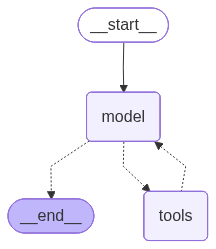

In [23]:
search_agent = create_agent(llm,tools=[tavily_tool,internal_tool_1])
search_agent

search node

In [24]:
def search_node(state: State) -> Command[Literal["supervisor"]]:
    result = search_agent.invoke(state)
    return Command(
        update={
            "messages":[
                HumanMessage(content=result["messages"][-1].content,name="search")
            ]
        },
        goto="supervisor"
    )

Web scrapper agent and node

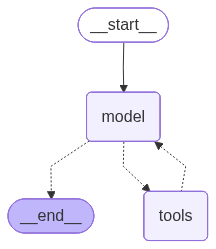

In [25]:
web_scrapper_agent = create_agent(
    llm,
    tools=[scrape_webpages]
)
web_scrapper_agent

In [26]:
def web_scrapper_node(state: State) -> Command[Literal["supervisor"]]:
    result = web_scrapper_agent.invoke(state)
    return Command(
        update={
            "messages":[
                HumanMessage(content=result["messages"][-1].content,name="web_scrapper")
            ]
        },
        goto="supervisor"
    )

building research supervisor

In [27]:
research_supervisor = make_supervisor_node(llm,["search","web_scrapper"])

building the graph

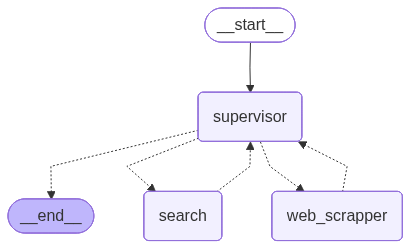

In [28]:
research_builder = StateGraph(State)
research_builder.add_node("supervisor",research_supervisor)
research_builder.add_node("search",search_node)
research_builder.add_node("web_scrapper",web_scrapper_node)
research_builder.add_edge(START,"supervisor")
research_graph = research_builder.compile()
research_graph

building the other side

doc writer agent and node

In [31]:
doc_writer_agent = create_agent(
    llm,
    tools=[write_document,edit_document,read_document],
    system_prompt=(
        "You can read, write and edit documents based on note-taker's outlines."
        "Dont ask follow-up questions."
    )
)

def doc_writing_node(state: State) -> Command[Literal["supervisor"]]:
    result = doc_writer_agent.invoke(state)
    return Command(
        update={
            "messages":[
                HumanMessage(content=result["messages"][-1].content,name="doc_writer")
            ]
        },
        goto = "doc_writer"
    )

note taking agent and node

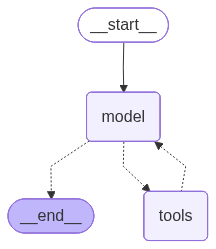

In [35]:
note_taking_agent = create_agent(
    llm,
    tools=[create_outline,read_document],
    system_prompt=(
        "You can read documents and create outline for the document writer."
        "Dont ask follow-up questions."
    )
)
note_taking_agent

In [36]:
def note_taking_node(state: State) -> Command[Literal["supervisor"]]:
    result = note_taking_agent.invoke(state)
    return Command(
        update={
            "messages":[
                HumanMessage(content=result["messages"][-1].content,name="note_taker")
            ]
        },
        goto = "supervisor"
    )

chart genearting agent

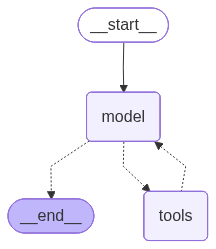

In [37]:
chart_generating_agent = create_agent(
    llm,
    tools=[read_document,python_repl_tool]
)
chart_generating_agent

In [39]:
def chart_generating_node(state: State) -> Command[Literal["supervisor"]]:
    result = chart_generating_agent.invoke(state)
    return Command(
        update={
            "messages":[
                HumanMessage(content=result["messages"][-1].content, name="chart_generator")
            ]
        },
        goto = "supervisor",
    )

building the doc writing supervisor

In [41]:
doc_writing_supervisor = make_supervisor_node(
    llm,
    ["doc_writer","note_taker","chart_generator"]
)

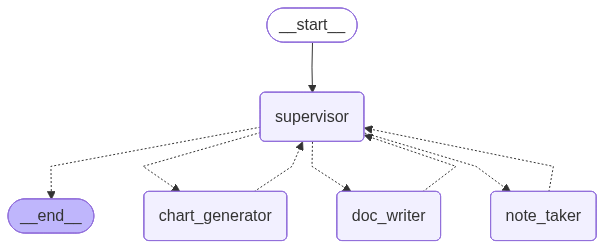

In [42]:
paper_writing_builder = StateGraph(State)
paper_writing_builder.add_node("supervisor",doc_writing_supervisor)
paper_writing_builder.add_node("doc_writer",doc_writing_node)
paper_writing_builder.add_node("note_taker",note_taking_node)
paper_writing_builder.add_node("chart_generator",chart_generating_node)
paper_writing_builder.add_edge(START,"supervisor")
paper_writing_graph = paper_writing_builder.compile()
paper_writing_graph

building the main supervisor

In [43]:
team_supervisor = make_supervisor_node(
    llm,
    ["research_team","writing_team"]
)

In [44]:
def call_research_team(state: State) -> Command[Literal["supervisor"]]:
    response = research_graph.invoke({"messages":state['messages'][-1]})
    return Command(
        update={
            "messages":[
                HumanMessage(
                    content=response["messages"][-1].content,
                    name="research_team"
                )
            ]
        },
        goto = "supervisor"
    )

def call_paper_writing_team(state: State) -> Command[Literal["supervisor"]]:
    response = paper_writing_graph.invoke({"messages":state['messages'][-1]})
    return Command(
        update={
            "messages":[
                HumanMessage(
                    content=response["messages"][-1].content,
                    name="research_team"
                )
            ]
        },
        goto = "supervisor"
    )

building final graph

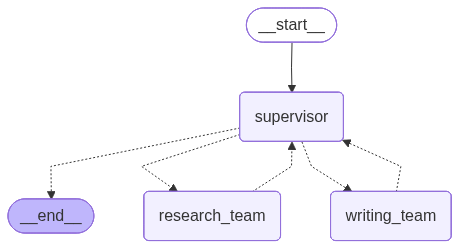

In [45]:
super_builder = StateGraph(State)
super_builder.add_node("supervisor",team_supervisor)
super_builder.add_node("research_team",call_research_team)
super_builder.add_node("writing_team",call_paper_writing_team)
super_builder.add_edge(START,"supervisor")
supergraph = super_builder.compile()
supergraph

testing out the system

In [46]:
response = supergraph.invoke(
    {
        "messages":[
            ("user","Research AI agents and write a brief report about them")
        ]
    }
)

BadRequestError: Error code: 400 - {'error': {'message': "tool call validation failed: parameters for tool ResearchNotesTool did not match schema: errors: [missing properties: '__arg1']", 'type': 'invalid_request_error', 'code': 'tool_use_failed', 'failed_generation': '<function=ResearchNotesTool>{"topic": "AI agents", "category": "research", "description": "A search for research notes on AI agents."}</function>'}}